# EDA — E-commerce Dataset
**Fuente:** `inferido_limpio.csv` (post-pipeline de limpieza)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np
from scipy.stats import chi2_contingency
from pathlib import Path

# Configuración de gráficos
sns.set_theme(style='whitegrid', palette='muted') 
plt.rcParams['figure.figsize'] = (10, 5)

# Cargar el dataset
data_path = Path.cwd().parent / "data" / "final" / "events_final.csv" # Ajusta la ruta según tu estructura de carpetas
df = pd.read_csv(data_path, parse_dates=['event_time']) # Asegúrate de que 'event_time' se parsea como fecha

# Eliminar la zona horaria de la columna 'event_time'
df['event_time'] = df['event_time'].dt.tz_localize(None)

# Mostrar las primeras filas del DataFrame y su forma
print(df.shape)
df.head(3)

(884312, 16)


,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,category_inferred,brand_inferred,nivel1,nivel2,nivel3,nivel2_norm,nivel3_norm
0,2020-09-24 11:57:06,view,1996170,2144415922528452715,electronics.telephone,generic.telephone,31.90,1515915625519388267,LJuJVLEjPT,False,True,electronics,telephone,NaN,telephone,NaN
1,2020-09-24 11:57:26,view,139905,2144415926932472027,computers.components.cooler,zalman,17.16,1515915625519380411,tdicluNnRY,False,False,computers,components,cooler,components,cooler
2,2020-09-24 11:57:27,view,215454,2144415927158964449,computers.accessories.cables,generic.cables,9.81,1515915625513238515,4TMArHtXQy,True,True,computers,accessories,cables,comp_accessories,cables


---
## 1. Distribución de event_type y embudo de conversión

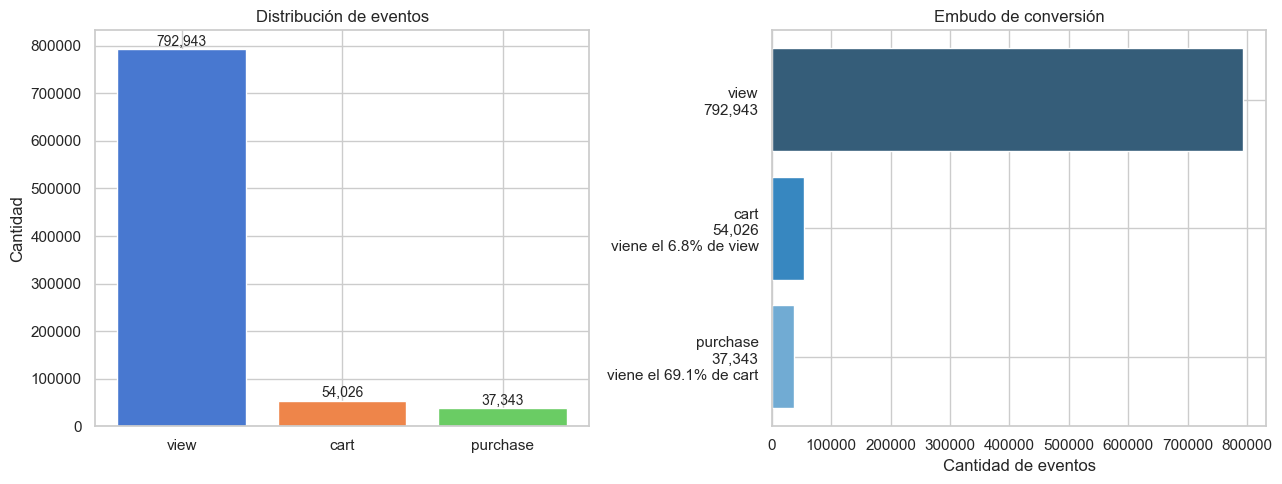

view → cart:           6.8%
cart → purchase:       69.1%
view → purchase total: 4.7%


In [7]:

counts = df['event_type'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Barras distribución
axes[0].bar(counts.index, counts.values, color=sns.color_palette('muted', len(counts)))
axes[0].set_title('Distribución de eventos')
axes[0].set_ylabel('Cantidad')
for i, (k, v) in enumerate(counts.items()):
    axes[0].text(i, v + counts.max()*0.01, f'{v:,}', ha='center', fontsize=10)

# Embudo con tasas de conversión entre pasos
funnel_order = [e for e in ['view', 'cart', 'purchase'] if e in counts.index]
funnel = counts[funnel_order]

conv_view_cart     = funnel.get('cart', 0)     / funnel.get('view', 1) * 100
conv_cart_purchase = funnel.get('purchase', 0) / funnel.get('cart', 1) * 100
conv_view_purchase = funnel.get('purchase', 0) / funnel.get('view', 1) * 100

etiquetas = {
    'view':     f"view\n{funnel.get('view',0):,}",
    'cart':     f"cart\n{funnel.get('cart',0):,}\nviene el {conv_view_cart:.1f}% de view",
    'purchase': f"purchase\n{funnel.get('purchase',0):,}\nviene el {conv_cart_purchase:.1f}% de cart",
}

labels = [etiquetas[e] for e in funnel_order]
bars = axes[1].barh(labels[::-1], funnel.values[::-1],
                    color=sns.color_palette('Blues_d', len(funnel)))
axes[1].set_title('Embudo de conversión')
axes[1].set_xlabel('Cantidad de eventos')

plt.tight_layout()
plt.show()

print(f'view → cart:           {conv_view_cart:.1f}%')
print(f'cart → purchase:       {conv_cart_purchase:.1f}%')
print(f'view → purchase total: {conv_view_purchase:.1f}%')


---
## 2. Distribución de eventos por usuario
> Clave para entender cold start: ¿cuántos usuarios tienen muy pocas interacciones?

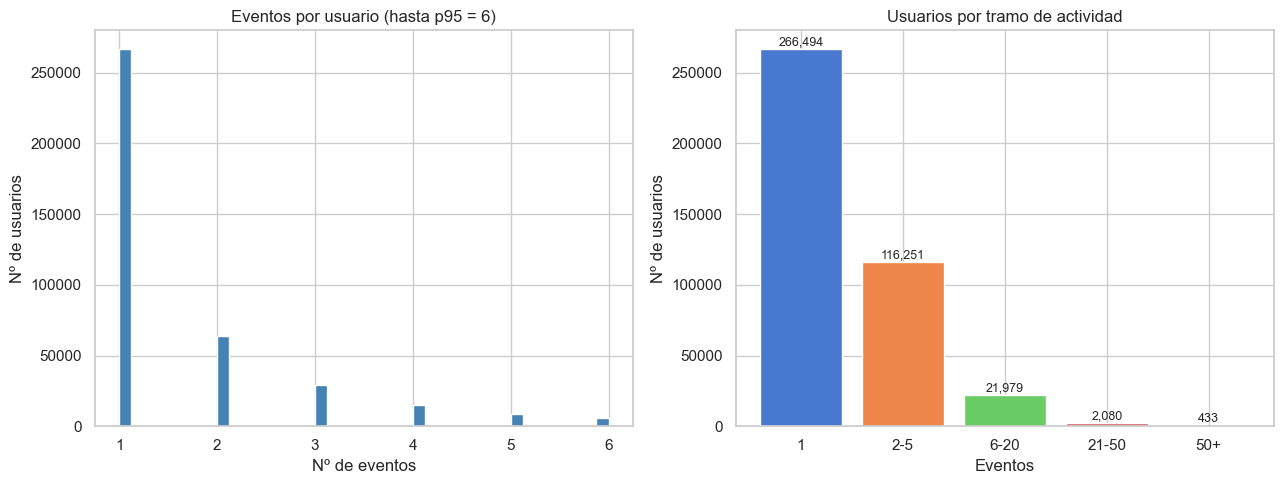

Usuarios únicos:     407,237
Mediana de eventos:  1
Media de eventos:    2.2
Usuarios con ≤5 eventos (cold start): 382,745 (94.0%)


In [8]:
# Análisis de eventos por usuario
eventos_por_usuario = df.groupby('user_id').size()

# Visualizaciones
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Histograma (con cap para evitar outliers extremos)
cap = eventos_por_usuario.quantile(0.95)
datos_plot = eventos_por_usuario[eventos_por_usuario <= cap]
axes[0].hist(datos_plot, bins=40, color='steelblue', edgecolor='white')
axes[0].set_title(f'Eventos por usuario (hasta p95 = {cap:.0f})')
axes[0].set_xlabel('Nº de eventos')
axes[0].set_ylabel('Nº de usuarios')

# Distribución por tramos para saber cuántos usuarios tienen 1 evento, 2-5, 6-20, etc.
tramos = pd.cut(eventos_por_usuario,
                bins=[0, 1, 5, 20, 50, float('inf')],
                labels=['1', '2-5', '6-20', '21-50', '50+'])
tramo_counts = tramos.value_counts().sort_index()
axes[1].bar(tramo_counts.index.astype(str), tramo_counts.values, color=sns.color_palette('muted', 5))
axes[1].set_title('Usuarios por tramo de actividad')
axes[1].set_xlabel('Eventos')
axes[1].set_ylabel('Nº de usuarios')
for i, v in enumerate(tramo_counts.values):
    axes[1].text(i, v + tramo_counts.max()*0.01, f'{v:,}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

print(f'Usuarios únicos:     {eventos_por_usuario.shape[0]:,}')
print(f'Mediana de eventos:  {eventos_por_usuario.median():.0f}')
print(f'Media de eventos:    {eventos_por_usuario.mean():.1f}')
cold = (eventos_por_usuario <= 5).sum() # Usuarios con 1 a 5 eventos (cold start)
print(f'Usuarios con ≤5 eventos (cold start): {cold:,} ({cold/len(eventos_por_usuario)*100:.1f}%)')

---
## 3. Productos más vistos y más comprados

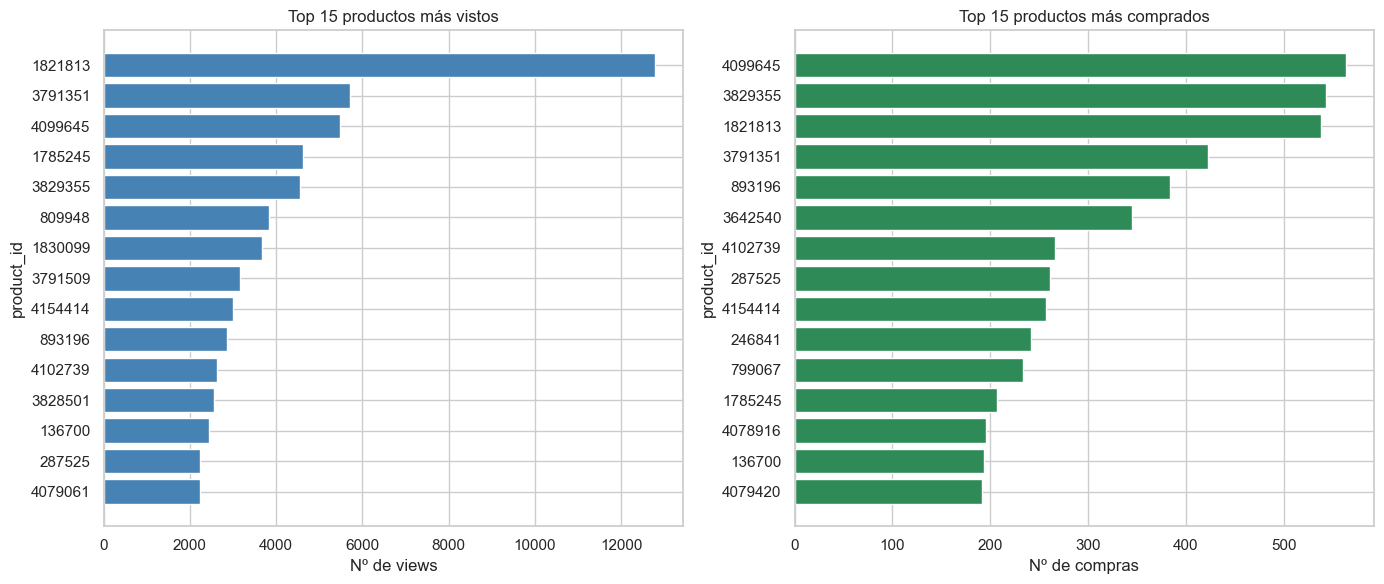

Productos únicos en el dataset: 53,452


In [9]:
# Análisis de productos más vistos y comprados
top_n = 15
views    = df[df['event_type'] == 'view'].groupby('product_id').size().nlargest(top_n)
compras  = df[df['event_type'] == 'purchase'].groupby('product_id').size().nlargest(top_n)

# Visualización de los top productos
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].barh(views.index.astype(str)[::-1], views.values[::-1], color='steelblue')
axes[0].set_title(f'Top {top_n} productos más vistos')
axes[0].set_xlabel('Nº de views')
axes[0].set_ylabel('product_id')

axes[1].barh(compras.index.astype(str)[::-1], compras.values[::-1], color='seagreen')
axes[1].set_title(f'Top {top_n} productos más comprados')
axes[1].set_xlabel('Nº de compras')
axes[1].set_ylabel('product_id')

plt.tight_layout()
plt.show()

print(f'Productos únicos en el dataset: {df["product_id"].nunique():,}')

---
## 4. Categorías más activas (nivel1, nivel2, nivel3)

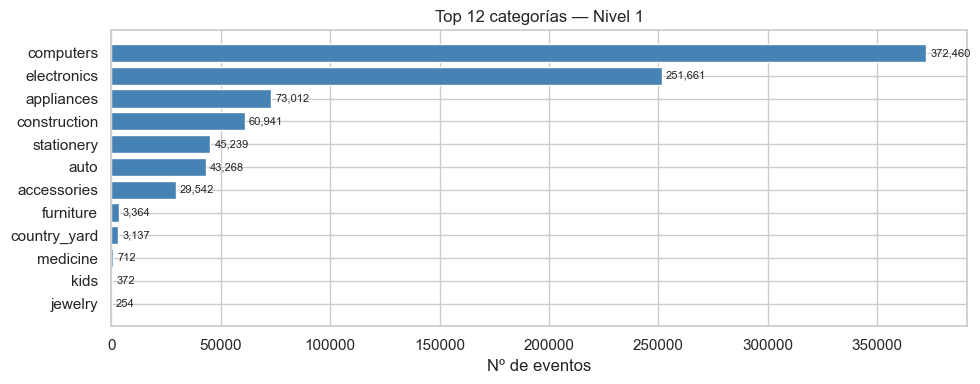

Nivel 1: 14 categorías únicas



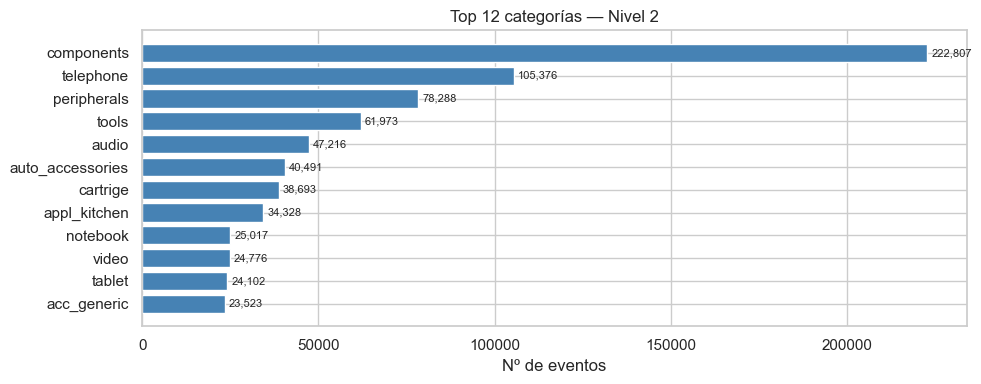

Nivel 2: 79 categorías únicas



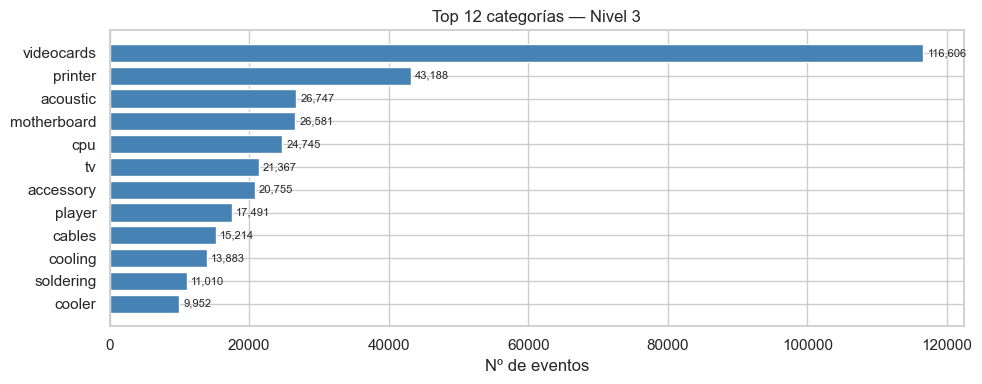

Nivel 3: 155 categorías únicas



In [10]:
# Análisis de categorías más comunes en cada nivel
top_n = 12
# Para cada nivel de categoría, mostrar las top categorías y su cantidad, con una barra horizontal y el número al lado.
for nivel, col in [('Nivel 1', 'nivel1'), ('Nivel 2', 'nivel2_norm'), ('Nivel 3', 'nivel3_norm')]:
    data = df[col].value_counts().dropna().head(top_n)
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.barh(data.index[::-1], data.values[::-1], color='steelblue')
    ax.set_title(f'Top {top_n} categorías — {nivel}')
    ax.set_xlabel('Nº de eventos')
    for i, v in enumerate(data.values[::-1]):
        ax.text(v + data.max()*0.005, i, f'{v:,}', va='center', fontsize=8)
    plt.tight_layout()
    plt.show()
    print(f'{nivel}: {df[col].nunique()} categorías únicas\n')

---
## 5. Evolución temporal de eventos (por semana / mes)
> Para detectar estacionalidad: Black Friday, Navidad, etc.

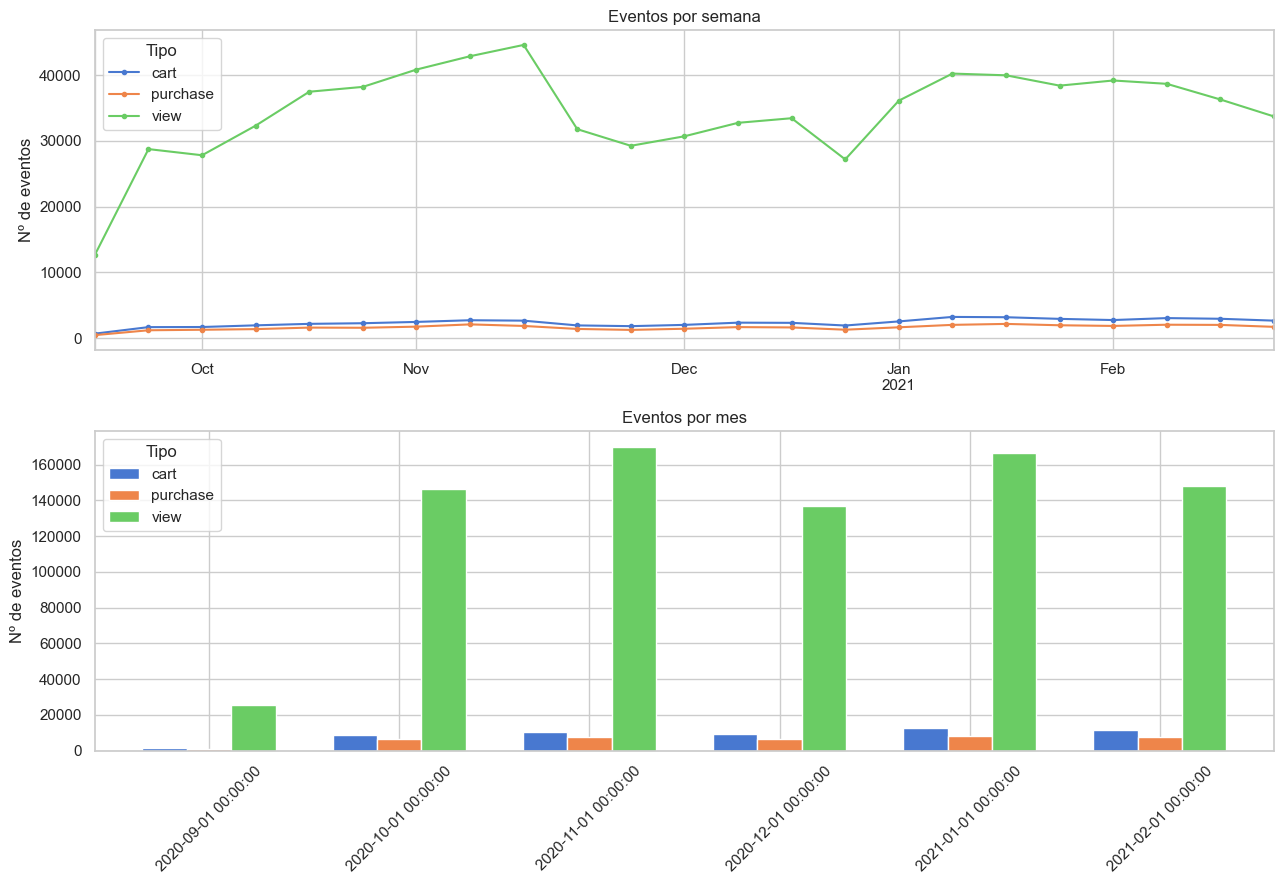

In [11]:
# Análisis temporal de eventos para ver tendencias por semana y mes, y si hay estacionalidad o picos en ciertos momentos.
df['semana']    = df['event_time'].dt.to_period('W').dt.start_time
df['mes']       = df['event_time'].dt.to_period('M').dt.start_time

fig, axes = plt.subplots(2, 1, figsize=(13, 9))

# Por semana y tipo de evento
semanal = df.groupby(['semana', 'event_type']).size().unstack(fill_value=0)
semanal.plot(ax=axes[0], marker='o', markersize=3)
axes[0].set_title('Eventos por semana')
axes[0].set_xlabel('')
axes[0].set_ylabel('Nº de eventos')
axes[0].legend(title='Tipo')

# Por mes y tipo de evento
mensual = df.groupby(['mes', 'event_type']).size().unstack(fill_value=0)
mensual.plot(kind='bar', ax=axes[1], width=0.7)
axes[1].set_title('Eventos por mes')
axes[1].set_xlabel('')
axes[1].set_ylabel('Nº de eventos')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(title='Tipo')

plt.tight_layout()
plt.show()

---
## 6. Patrones por hora del día y día de la semana

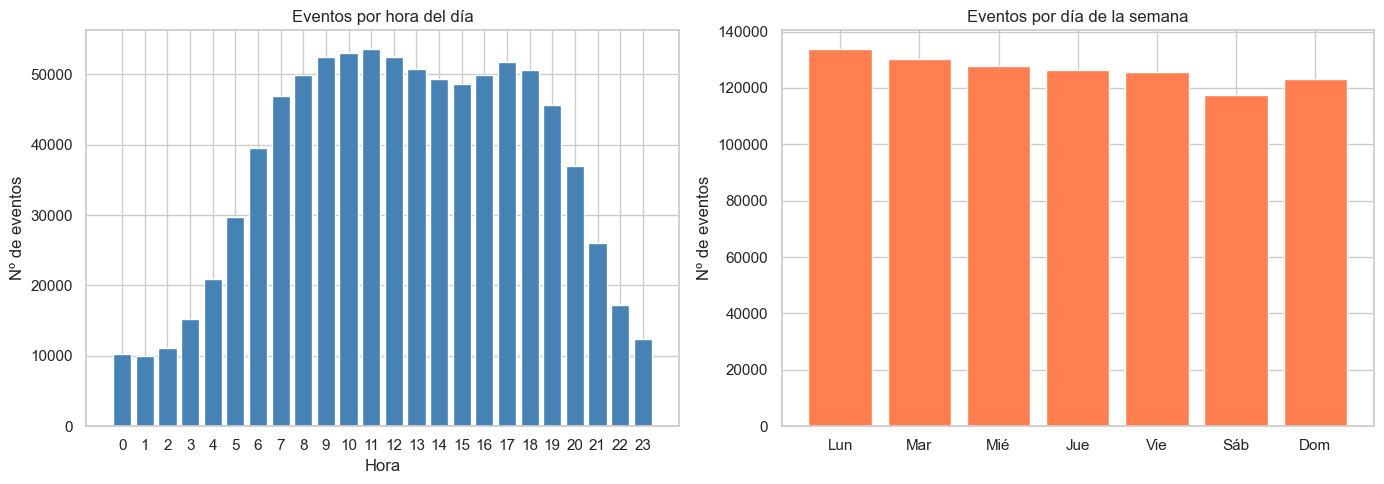

In [12]:
#definir hora y día de la semana para analizar patrones diarios y semanales
df['hora']         = df['event_time'].dt.hour
df['dia_semana']   = df['event_time'].dt.day_name()

orden_dias = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Por hora
hora_counts = df.groupby('hora').size()
axes[0].bar(hora_counts.index, hora_counts.values, color='steelblue', edgecolor='white')
axes[0].set_title('Eventos por hora del día')
axes[0].set_xlabel('Hora')
axes[0].set_ylabel('Nº de eventos')
axes[0].set_xticks(range(0, 24))

# Por día de la semana
dia_counts = df.groupby('dia_semana').size().reindex(orden_dias)
axes[1].bar(range(len(dia_counts)), dia_counts.values, color='coral', edgecolor='white')
axes[1].set_title('Eventos por día de la semana')
axes[1].set_xticks(range(len(orden_dias)))
axes[1].set_xticklabels(['Lun','Mar','Mié','Jue','Vie','Sáb','Dom'])
axes[1].set_ylabel('Nº de eventos')

plt.tight_layout()
plt.show()

---
## 7. Distribución de precios por categoría (nivel1)

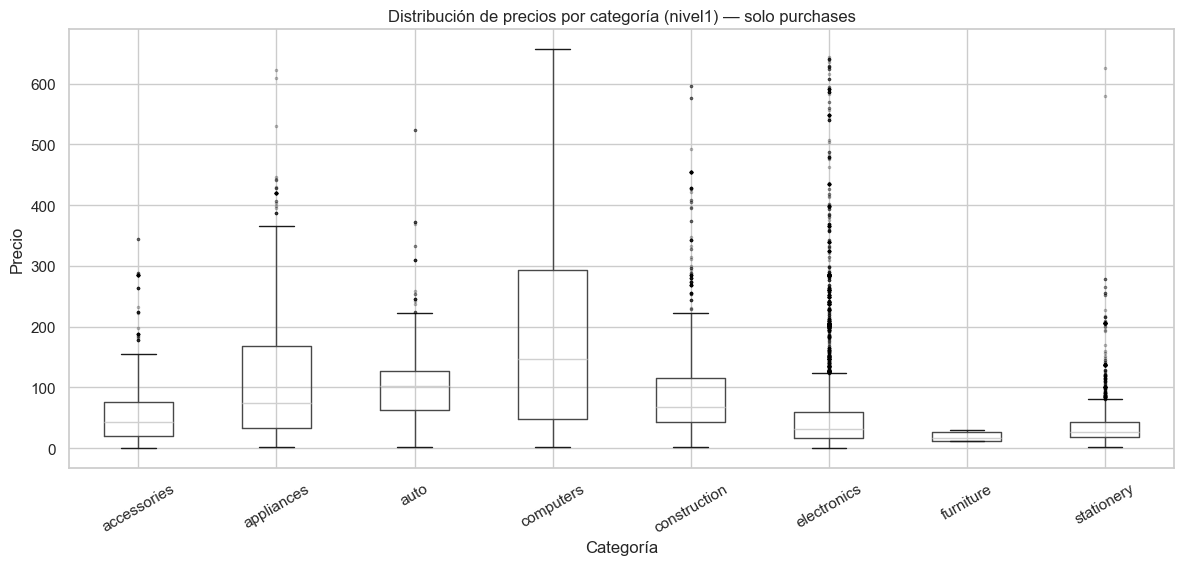

              median    mean     max
nivel1                              
computers     147.13  188.57  656.63
electronics    31.59   60.96  643.89
stationery     26.19   38.42  625.14
construction   68.10   92.72  596.84
appliances     74.95  110.77  622.84
auto          102.46   98.29  523.65
accessories    43.03   67.77  344.44
furniture      16.19   18.18   30.16


In [13]:
# Solo purchases para reflejar precios reales pagados con cap para evitar outliers extremos
df_precio = df[df['event_type'] == 'purchase'].copy()
p99 = df_precio['price'].quantile(0.99)
df_precio = df_precio[df_precio['price'] <= p99]

# Top 8 categorías nivel1 por volumen de compras
top_cats = df_precio['nivel1'].value_counts().head(8).index
df_plot = df_precio[df_precio['nivel1'].isin(top_cats)]

fig, ax = plt.subplots(figsize=(12, 6))
df_plot.boxplot(column='price', by='nivel1', ax=ax, 
                flierprops=dict(marker='.', markersize=3, alpha=0.3))
ax.set_title('Distribución de precios por categoría (nivel1) — solo purchases')
fig.suptitle('')
ax.set_xlabel('Categoría')
ax.set_ylabel('Precio')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

print(df_precio.groupby('nivel1')['price'].agg(['median','mean','max']).loc[top_cats].round(2))

---
## 8. Tasa de conversión view → cart → purchase por categoría (nivel1)

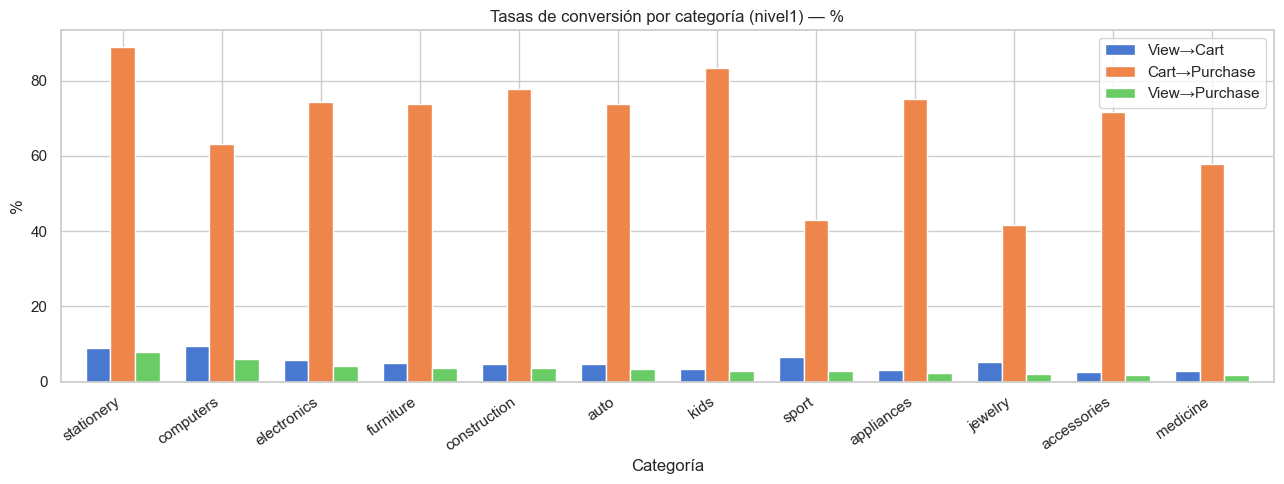

event_type    conv_view_cart  conv_cart_purchase  conv_view_purchase
nivel1                                                              
stationery              8.80               88.87                7.82
computers               9.33               63.15                5.89
electronics             5.59               74.35                4.15
furniture               5.04               73.72                3.72
construction            4.73               77.83                3.68
auto                    4.63               73.85                3.42
kids                    3.43               83.33                2.86
sport                   6.60               42.86                2.83
appliances              3.06               75.07                2.30
jewelry                 5.06               41.67                2.11
accessories             2.60               71.60                1.86
medicine                2.79               57.89                1.61


In [14]:
#definimos el pivot para analizar tasas de conversión entre views, carts y purchases por categoría (nivel1)
pivot = (
    df.groupby(['nivel1', 'event_type'])
    .size()
    .unstack(fill_value=0)
)

# Solo categorías con al menos 100 views
if 'view' in pivot.columns:
    pivot = pivot[pivot['view'] >= 100]

if 'purchase' in pivot.columns and 'view' in pivot.columns:
    pivot['conv_view_purchase'] = (pivot['purchase'] / pivot['view'] * 100).round(2)
if 'cart' in pivot.columns and 'view' in pivot.columns:
    pivot['conv_view_cart'] = (pivot['cart'] / pivot['view'] * 100).round(2)
if 'purchase' in pivot.columns and 'cart' in pivot.columns:
    pivot['conv_cart_purchase'] = (pivot['purchase'] / pivot['cart'] * 100).round(2)

conv_cols = [c for c in ['conv_view_cart', 'conv_cart_purchase', 'conv_view_purchase'] if c in pivot.columns]
conv = pivot[conv_cols].sort_values('conv_view_purchase', ascending=False).head(12)

conv.plot(kind='bar', figsize=(13, 5), width=0.75)
plt.title('Tasas de conversión por categoría (nivel1) — %')
plt.xlabel('Categoría')
plt.ylabel('%')
plt.xticks(rotation=35, ha='right')
plt.legend(['View→Cart', 'Cart→Purchase', 'View→Purchase'])
plt.tight_layout()
plt.show()

print(conv)

---
## 9. Dispersión de la matriz usuario-producto
 interacciones existentes nos dice qué tan dispersa está la matriz usuario-producto, lo cual es crucial para recomendar productos a usuarios nuevos o poco activos.
 celdas vacias nos dice qué tan difícil será recomendar productos a usuarios nuevos o poco activos, ya que no hay datos de interacciones previas para basar las recomendaciones.

Usuarios únicos:       407,237
Productos únicos:      53,452
Pares usuario-producto únicos: 556,637
Celdas totales posibles:       21,767,632,124
Sparsity:              99.9974%


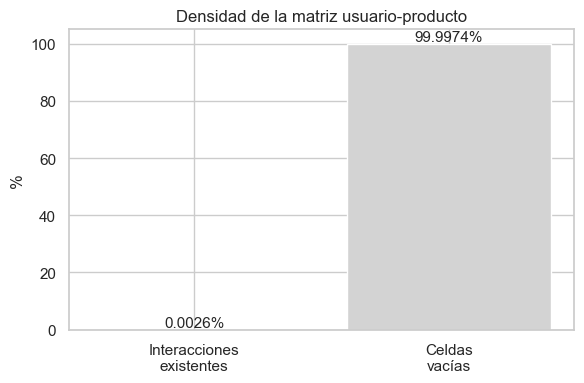

In [15]:
#definimos la matriz usuario-producto para analizar su sparsity
n_usuarios  = df['user_id'].nunique()
n_productos = df['product_id'].nunique()
n_interacciones = df[['user_id', 'product_id']].drop_duplicates().shape[0]

total_celdas = n_usuarios * n_productos
sparsity = 1 - (n_interacciones / total_celdas)

print(f'Usuarios únicos:       {n_usuarios:,}') # Número de usuarios únicos en el dataset
print(f'Productos únicos:      {n_productos:,}') # Número de productos únicos en el dataset
print(f'Pares usuario-producto únicos: {n_interacciones:,}') # Número de combinaciones únicas de usuario-producto con al menos una interacción
print(f'Celdas totales posibles:       {total_celdas:,}') # Total de combinaciones usuario-producto
print(f'Sparsity:              {sparsity*100:.4f}%') # Porcentaje de celdas vacías en la matriz usuario-producto

# Visualización simple para mostrar la proporción de interacciones existentes vs celdas vacías
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(['Interacciones\nexistentes', 'Celdas\nvacías'],
       [n_interacciones / total_celdas * 100, sparsity * 100],
       color=['steelblue', 'lightgray'], edgecolor='white')
ax.set_ylabel('%')
ax.set_title('Densidad de la matriz usuario-producto')
ax.set_ylim(0, 105)
for i, v in enumerate([n_interacciones / total_celdas * 100, sparsity * 100]):
    ax.text(i, v + 1, f'{v:.4f}%', ha='center', fontsize=11)
plt.tight_layout()
plt.show()

---
## 10. Matriz de correlación entre variables numéricas

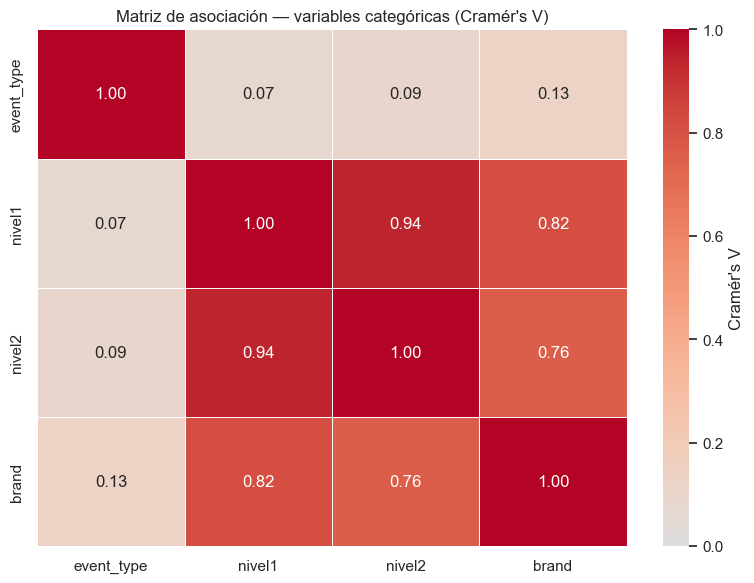

In [18]:
# Para analizar la asociación entre variables categóricas, utilizamos Cramér's V
# , que es una medida de asociación basada en el chi-cuadrado.
def cramers_v(x, y):
    ct = pd.crosstab(x.fillna(''), y.fillna(''))
    chi2 = chi2_contingency(ct)[0]
    n = ct.values.sum()
    r, k = ct.shape
    denom = n * (min(r, k) - 1)
    return np.sqrt(chi2 / denom) if denom > 0 else 0.0

cols_cat = ['event_type', 'nivel1', 'nivel2', 'brand']
corr = pd.DataFrame(
    [[cramers_v(df[c1], df[c2]) for c2 in cols_cat] for c1 in cols_cat],
    index=cols_cat, columns=cols_cat
)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(data=corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, linecolor='white', ax=ax,
            cbar_kws={'label': "Cramér's V"}, vmin=0, vmax=1)
ax.set_title("Matriz de asociación — variables categóricas (Cramér's V)")
plt.tight_layout()
plt.show()


---
## 11. Matriz de asociación entre variables categóricas 
> Cramér's V mide la asociación entre variables categóricas: 0 = sin relación, 1 = asociación perfecta.

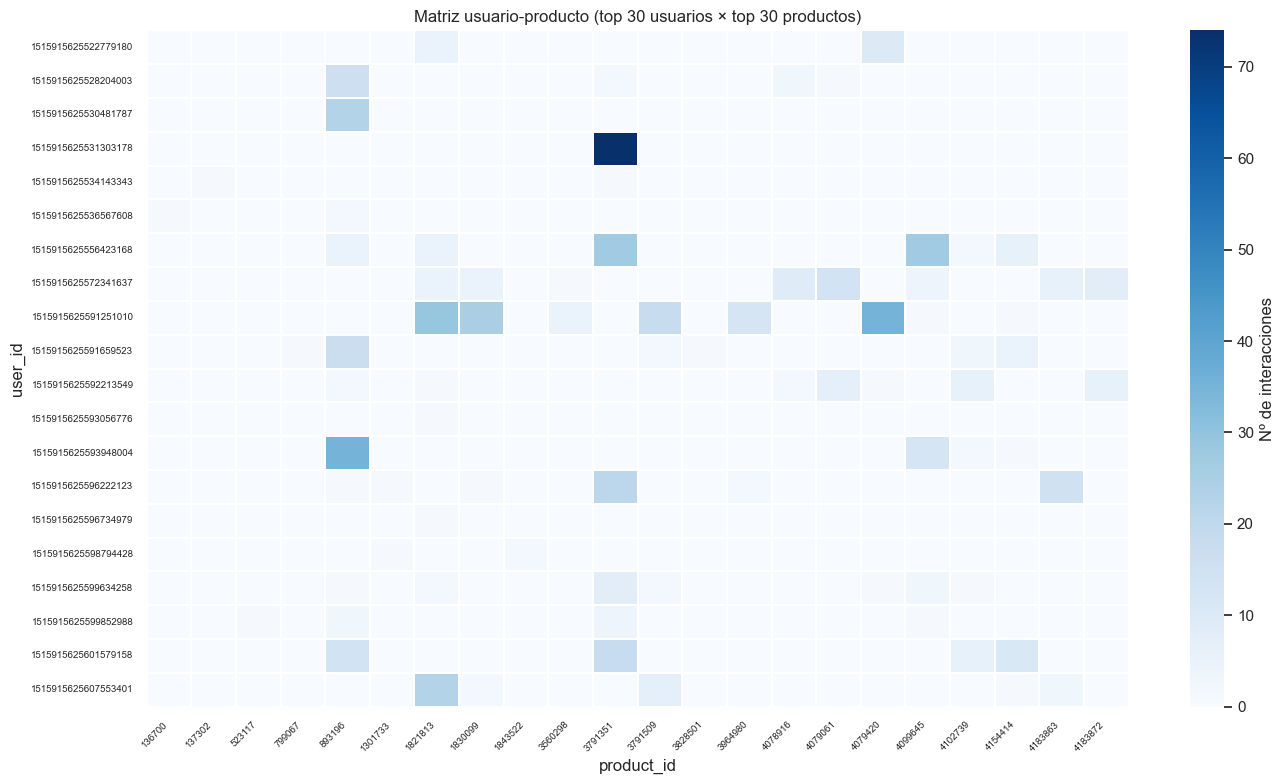

In [17]:
# Tomar los 30 usuarios y 30 productos más activos para que sea legible
top_users    = df['user_id'].value_counts().head(30).index
top_products = df['product_id'].value_counts().head(30).index

sub = df[df['user_id'].isin(top_users) & df['product_id'].isin(top_products)]

# Contar interacciones (todos los event_type como señal implícita)
matriz = sub.groupby(['user_id', 'product_id']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(matriz, cmap='Blues', linewidths=0.3, linecolor='white',
            ax=ax, cbar_kws={'label': 'Nº de interacciones'})
ax.set_title('Matriz usuario-producto (top 30 usuarios × top 30 productos)')
ax.set_xlabel('product_id')
ax.set_ylabel('user_id')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=7)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=7)
plt.tight_layout()
plt.show()


---
## Conclusiones del EDA

1. **El 89% de los eventos son views y solo el 4% son compras.** Los usuarios navegan mucho sin comprar. El modelo va a considerar todas las interacciones como señal, dándole más peso a las compras que a las vistas.

2. **El 94% de los usuarios tiene ≤5 interacciones (cold start), con mediana de 1 evento.** El sistema prácticamente no los conoce. Vamos a recomendar a estos usuarios los productos más comprados dentro de las categorías nivel 1 y/o nivel 2 que exploraron.

3. **Hay productos claramente más populares que otros.** Estos van a ser la base del modelo de referencia: si no sabemos nada de un usuario, le recomendamos lo más comprado.

4. **Las categorías de nivel 2 tienen el balance justo entre detalle y volumen.** Nivel 1 es demasiado general (solo 14 categorías) y nivel 3 tiene muy pocos datos en muchos casos (140 categorías, con colas muy largas). Veremos si es conveniente trabajar con nivel 2 como referencia principal para las recomendaciones.

5. **El pico de actividad se da en noviembre (probablemente Black Friday), mientras que diciembre registra una caída relativa.** Noviembre es el mes con más views (~165k), diciembre baja a ~138k, y enero 2021 vuelve a subir a ~163k. No hay un pico de fin de año en diciembre; el patrón no sigue una estacionalidad navideña evidente.

6. **La actividad se concentra en una franja horaria diurna amplia (10h–18h, ~50–53k eventos/hora), con mínimo en la madrugada (~10k).** Por día de la semana, la diferencia entre días hábiles y fin de semana es moderada: el lunes es el más activo (~133k eventos) y el sábado el menos activo (~117k), una diferencia de apenas ~14%.

7. **El precio varía mucho entre categorías.** La mediana va desde 16 (furniture) hasta 147 (computers). Lo vamos a normalizar dentro de cada categoría antes de usarlo, para que sea comparable entre productos de distintos segmentos.

8. **Algunas categorías convierten mucho más que otras.** Stationery lidera con 7.82% de conversión view→purchase, seguida de computers (5.89%). Medicine es la más baja con 1.61%. Las de mayor conversión son las más valiosas para el negocio y van a ser las prioritarias en las recomendaciones.

9. **Casi ningún usuario interactuó con casi ningún producto (sparsity del 99.9974%).** Esto confirma que necesitamos un modelo diseñado para trabajar con datos incompletos, como el filtrado colaborativo (hay 2 variantes: basado en usuarios que busca usuarios parecidos a uno y recomienda lo que ellos compraron, y basado en ítems que busca productos que suelen comprarse juntos y recomienda el complemento). Esto fallaria en coldstart por eso sera un tratamiento distinto a esta problematica.

10. **La categoría determina casi por completo la marca: nivel1↔nivel2 tienen una asociación de 0.94 (prácticamente redundantes entre sí), y ambas predicen fuertemente la marca (0.82 y 0.76). Esto confirma que los productos están muy segmentados por categoría-marca. En cambio, el tipo de evento (view/cart/purchase) es casi independiente de la categoría y la marca (0.07–0.13), lo que indica que el comportamiento del usuario no está sesgado hacia ninguna categoría en particular al momento de comprar versus solo navegar.**